# Bank Loan Portfolio Analysis — SQL (SQLite Edition)

## Business Problem
Financial institutions must balance loan growth with credit risk. This notebook rebuilds the project's original SQL Server analysis using **SQLite**, run entirely inside Python, so the full portfolio-performance analysis is reproducible without an external database server.

### Objectives
1. Load the raw loan-level data into a proper relational database (SQLite).
2. Answer portfolio-performance questions with SQL: volume, funding, repayment, rate, and risk KPIs.
3. Break the portfolio down by time, geography, term, employment tenure, purpose, home ownership, and **credit grade** (new in this version).
4. Produce a clean, numeric answer key that feeds the project's Business Requirements report — every figure below is generated live from the query, not hard-coded.

**Note on scope:** this notebook only covers *portfolio-level* SQL analysis (volumes, KPIs, breakdowns). Borrower-level risk drivers and predictive modeling are covered separately in the Python risk-analytics notebook to avoid duplicating findings.


In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
plt.rcParams['figure.figsize'] = (9, 4.5)


## 1. Load Data into SQLite

The raw CSV is loaded with pandas, date columns are parsed (`DD-MM-YYYY`), and the table is written into a fresh SQLite database file `bank_loan.db`. This mirrors the original SQL Server table `bank_loan_data` used in the source project.

In [2]:
df = pd.read_csv('financial_loan.csv')

date_cols = ['issue_date', 'last_credit_pull_date', 'last_payment_date', 'next_payment_date']
for c in date_cols:
    df[c] = pd.to_datetime(df[c], format='%d-%m-%Y', errors='coerce')

conn = sqlite3.connect('bank_loan.db')
df.to_sql('bank_loan_data', conn, if_exists='replace', index=False)

print(f"Loaded {len(df):,} rows and {df.shape[1]} columns into SQLite table 'bank_loan_data'.")
df.head()


Loaded 38,576 rows and 24 columns into SQLite table 'bank_loan_data'.


,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
0,1077430,GA,INDIVIDUAL,< 1 year,Ryder,C,RENT,2021-02-11,2021-09-13,2021-04-13,...,C4,60 months,Source Verified,"30,000.00",0.01,59.83,0.15,2500,4,1009
1,1072053,CA,INDIVIDUAL,9 years,MKC Accounting,E,RENT,2021-01-01,2021-12-14,2021-01-15,...,E1,36 months,Source Verified,"48,000.00",0.05,109.43,0.19,3000,4,3939
2,1069243,CA,INDIVIDUAL,4 years,Chemat Technology Inc,C,RENT,2021-01-05,2021-12-12,2021-01-09,...,C5,36 months,Not Verified,"50,000.00",0.21,421.65,0.16,12000,11,3522
3,1041756,TX,INDIVIDUAL,< 1 year,barnes distribution,B,MORTGAGE,2021-02-25,2021-12-12,2021-03-12,...,B2,60 months,Source Verified,"42,000.00",0.05,97.06,0.11,4500,9,4911
4,1068350,IL,INDIVIDUAL,10+ years,J&J Steel Inc,A,MORTGAGE,2021-01-01,2021-12-14,2021-01-15,...,A1,36 months,Verified,"83,000.00",0.02,106.53,0.06,3500,28,3835


In [3]:
def run_sql(query, conn=conn):
    return pd.read_sql(query, conn)


## 2. Data Quality Check (SQL)

SQLite has no native `MONTH()`/`YEAR()` functions — this version uses `strftime('%m', issue_date)` and `strftime('%Y', issue_date)` instead, which is the main syntax change versus the original SQL Server queries.

In [4]:
dq = run_sql('''
SELECT
    COUNT(*)                                  AS total_rows,
    COUNT(*) - COUNT(id)                      AS null_id,
    COUNT(*) - COUNT(loan_amount)             AS null_loan_amount,
    COUNT(*) - COUNT(issue_date)              AS null_issue_date,
    COUNT(DISTINCT id)                        AS distinct_ids
FROM bank_loan_data;
''')
dq


,total_rows,null_id,null_loan_amount,null_issue_date,distinct_ids
0,38576,0,0,0,38576


**Insight:** The table contains 38,576 rows with no missing IDs, funded amounts, or issue dates, and every `id` is unique — the dataset is clean and ready for KPI analysis without further deduplication.

## 3. Portfolio Summary KPIs

Total applications, funding, repayments, average rate, and average DTI — the headline numbers that anchor the Power BI Summary page — reproduced here directly from SQLite for full traceability.

In [5]:
kpi = run_sql('''
SELECT
    COUNT(id)                              AS Total_Loan_Applications,
    SUM(loan_amount)                       AS Total_Funded_Amount,
    SUM(total_payment)                     AS Total_Amount_Received,
    ROUND(AVG(int_rate) * 100, 2)          AS Average_Interest_Rate,
    ROUND(AVG(dti) * 100, 2)               AS Average_DTI
FROM bank_loan_data;
''')
kpi


,Total_Loan_Applications,Total_Funded_Amount,Total_Amount_Received,Average_Interest_Rate,Average_DTI
0,38576,435757075,473070933,12.05,13.33


In [6]:
mtd = run_sql('''
SELECT
    strftime('%m', issue_date) AS month_num,
    COUNT(id) AS Applications,
    SUM(loan_amount) AS Funded_Amount,
    SUM(total_payment) AS Amount_Received,
    ROUND(AVG(int_rate) * 100, 2) AS Avg_Interest_Rate,
    ROUND(AVG(dti) * 100, 2) AS Avg_DTI
FROM bank_loan_data
WHERE strftime('%Y', issue_date) = '2021' AND strftime('%m', issue_date) IN ('11','12')
GROUP BY month_num
ORDER BY month_num;
''')
mtd


,month_num,Applications,Funded_Amount,Amount_Received,Avg_Interest_Rate,Avg_DTI
0,11,4035,47754825,50132030,11.94,13.30
1,12,4314,53981425,58074380,12.36,13.67


**Insight:** The bank processed 38,576 applications for \$435.8M funded against \$473.1M received — repayments already exceed funded principal at the portfolio level. December applications (4,314), funding (\$54.0M) and rate (12.36%) all rose versus November, while average DTI also drifted up MoM (13.33% → 13.67%), consistent with the Power BI Summary page.

## 4. Good Loan vs Bad Loan Classification

In [7]:
status_mix = run_sql('''
SELECT
    CASE WHEN loan_status IN ('Fully Paid','Current') THEN 'Good Loan' ELSE 'Bad Loan' END AS loan_category,
    COUNT(id) AS Applications,
    SUM(loan_amount) AS Funded_Amount,
    SUM(total_payment) AS Amount_Received,
    ROUND(100.0 * COUNT(id) / (SELECT COUNT(*) FROM bank_loan_data), 2) AS Pct_of_Book
FROM bank_loan_data
GROUP BY loan_category;
''')
status_mix


,loan_category,Applications,Funded_Amount,Amount_Received,Pct_of_Book
0,Bad Loan,5333,65532225,37284763,13.82
1,Good Loan,33243,370224850,435786170,86.18


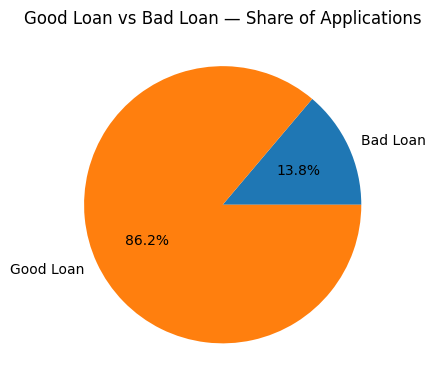

In [8]:
status_mix.set_index('loan_category')[['Applications']].plot(kind='pie', y='Applications', autopct='%1.1f%%', legend=False, ylabel='')
plt.title('Good Loan vs Bad Loan — Share of Applications')
plt.show()


**Insight:** 86.2% of the book (33,243 loans, \$370.2M funded) is Good Loan; 13.8% (5,333 loans, \$65.5M funded) is Bad Loan (Charged Off), of which only \$37.3M was recovered — a net shortfall of roughly \$28.2M on the charged-off cohort alone.

In [9]:
status_detail = run_sql('''
SELECT
    loan_status,
    COUNT(id) AS Applications,
    SUM(loan_amount) AS Funded_Amount,
    SUM(total_payment) AS Amount_Received,
    ROUND(AVG(int_rate) * 100, 2) AS Avg_Interest_Rate,
    ROUND(AVG(dti) * 100, 2) AS Avg_DTI
FROM bank_loan_data
GROUP BY loan_status
ORDER BY Applications DESC;
''')
status_detail


,loan_status,Applications,Funded_Amount,Amount_Received,Avg_Interest_Rate,Avg_DTI
0,Fully Paid,32145,351358350,411586256,11.64,13.17
1,Charged Off,5333,65532225,37284763,13.88,14.00
2,Current,1098,18866500,24199914,15.10,14.72


**Insight:** Charged-Off loans carry the highest average interest rate (13.9%) and DTI (14.0%) of any status — both variables run hotter for loans that ultimately default, foreshadowing the Python model's finding that rate and DTI are the leading risk drivers.

## 5. Monthly Trend Analysis

In [10]:
monthly = run_sql('''
SELECT
    strftime('%m', issue_date) AS month_num,
    CASE strftime('%m', issue_date)
        WHEN '01' THEN 'Jan' WHEN '02' THEN 'Feb' WHEN '03' THEN 'Mar' WHEN '04' THEN 'Apr'
        WHEN '05' THEN 'May' WHEN '06' THEN 'Jun' WHEN '07' THEN 'Jul' WHEN '08' THEN 'Aug'
        WHEN '09' THEN 'Sep' WHEN '10' THEN 'Oct' WHEN '11' THEN 'Nov' WHEN '12' THEN 'Dec'
    END AS month_name,
    COUNT(id) AS Applications,
    SUM(loan_amount) AS Funded_Amount,
    SUM(total_payment) AS Received_Amount
FROM bank_loan_data
GROUP BY month_num
ORDER BY month_num;
''')
monthly


,month_num,month_name,Applications,Funded_Amount,Received_Amount
0,01,Jan,2332,25031650,27578836
1,02,Feb,2279,24647825,27717745
2,03,Mar,2627,28875700,32264400
3,04,Apr,2755,29800800,32495533
4,05,May,2911,31738350,33750523
5,06,Jun,3184,34161475,36164533
6,07,Jul,3366,35813900,38827220
7,08,Aug,3441,38149600,42682218
8,09,Sep,3536,40907725,43983948
9,10,Oct,3796,44893800,49399567


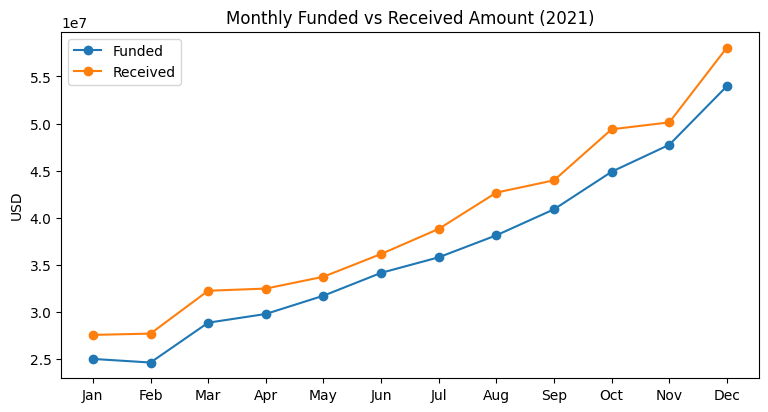

In [11]:
fig, ax = plt.subplots()
ax.plot(monthly['month_name'], monthly['Funded_Amount'], marker='o', label='Funded')
ax.plot(monthly['month_name'], monthly['Received_Amount'], marker='o', label='Received')
ax.set_title('Monthly Funded vs Received Amount (2021)')
ax.set_ylabel('USD')
ax.legend()
plt.show()


**Insight:** Applications, funding and repayments all climbed steadily from January (\$25.0M funded) to December (\$54.0M funded) — roughly doubling across the year with no seasonal dips, indicating consistent portfolio growth rather than a one-off spike.

## 6. Geographic Analysis (Top States)

In [12]:
state_analysis = run_sql('''
SELECT
    address_state,
    COUNT(id) AS Applications,
    SUM(loan_amount) AS Funded_Amount,
    SUM(total_payment) AS Received_Amount,
    ROUND(100.0 * SUM(CASE WHEN loan_status = 'Charged Off' THEN 1 ELSE 0 END) / COUNT(id), 2) AS Charge_Off_Rate_Pct
FROM bank_loan_data
GROUP BY address_state
ORDER BY Funded_Amount DESC
LIMIT 10;
''')
state_analysis


,address_state,Applications,Funded_Amount,Received_Amount,Charge_Off_Rate_Pct
0,CA,6894,78484125,83901234,15.33
1,NY,3701,42077050,46108181,12.65
2,TX,2664,31236650,34392715,11.30
3,FL,2773,30046125,31601905,17.27
4,NJ,1822,21657475,23425159,14.98
5,IL,1486,17124225,18875941,12.92
6,VA,1375,15982650,17711443,12.36
7,PA,1482,15826525,17462908,11.40
8,GA,1355,15480325,16728040,15.28
9,MA,1310,15051000,16676279,11.45


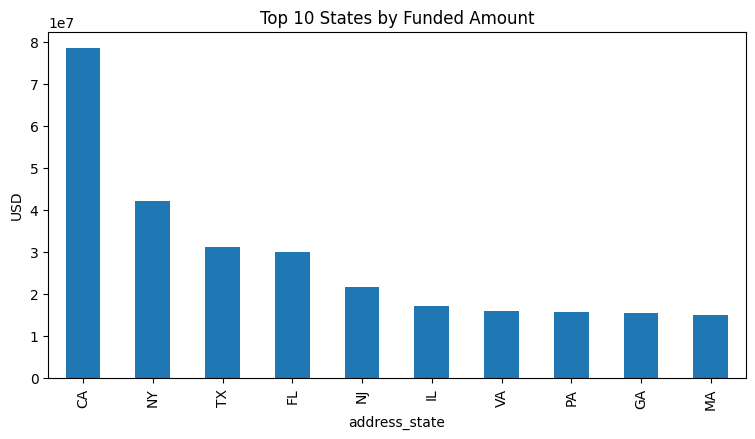

In [13]:
state_analysis.set_index('address_state')['Funded_Amount'].plot(kind='bar')
plt.title('Top 10 States by Funded Amount')
plt.ylabel('USD')
plt.show()


**Insight:** California (\$78.5M), New York (\$42.1M), Texas (\$31.2M) and Florida (\$30.0M) are the largest markets by funded amount, together accounting for roughly 41% of total funding — confirming these four states as the bank's core lending geography.

## 7. Loan Term Analysis

In [14]:
term_analysis = run_sql('''
SELECT
    term,
    COUNT(id) AS Applications,
    SUM(loan_amount) AS Funded_Amount,
    SUM(total_payment) AS Received_Amount,
    ROUND(100.0 * SUM(CASE WHEN loan_status='Charged Off' THEN 1 ELSE 0 END) / COUNT(id), 2) AS Charge_Off_Rate_Pct
FROM bank_loan_data
GROUP BY term
ORDER BY term;
''')
term_analysis


,term,Applications,Funded_Amount,Received_Amount,Charge_Off_Rate_Pct
0,36 months,28237,273041225,294709458,10.71
1,60 months,10339,162715850,178361475,22.34


**Insight:** 36-month loans account for nearly three-quarters of applications (28,237 vs 10,339) and carry a lower charge-off rate than 60-month loans — longer terms are both less popular and modestly riskier, useful context for pricing longer-tenor products.

## 8. Loan Purpose Analysis

In [15]:
purpose_analysis = run_sql('''
SELECT
    purpose,
    COUNT(id) AS Applications,
    SUM(loan_amount) AS Funded_Amount,
    SUM(total_payment) AS Received_Amount,
    ROUND(100.0 * SUM(CASE WHEN loan_status='Charged Off' THEN 1 ELSE 0 END) / COUNT(id), 2) AS Charge_Off_Rate_Pct
FROM bank_loan_data
GROUP BY purpose
ORDER BY Funded_Amount DESC;
''')
purpose_analysis


,purpose,Applications,Funded_Amount,Received_Amount,Charge_Off_Rate_Pct
0,Debt consolidation,18214,232459675,253801871,14.55
1,credit card,4998,58885175,65214084,10.16
2,home improvement,2876,33350775,36380930,11.37
3,other,3824,31155750,33289676,15.35
4,small business,1776,24123100,23814817,25.62
5,major purchase,2110,17251600,18676927,9.76
6,car,1497,10223575,11324914,10.35
7,wedding,928,9225800,10266856,9.27
8,medical,667,5533225,5851372,14.99
9,house,366,4824925,5185538,15.57


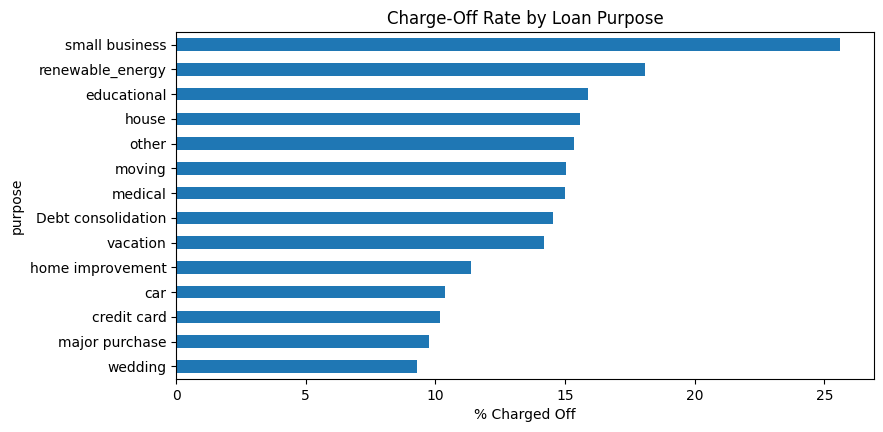

In [16]:
purpose_analysis.sort_values('Charge_Off_Rate_Pct', ascending=False).set_index('purpose')['Charge_Off_Rate_Pct'].plot(kind='barh')
plt.title('Charge-Off Rate by Loan Purpose')
plt.xlabel('% Charged Off')
plt.gca().invert_yaxis()
plt.show()


**Insight:** Debt Consolidation is the largest purpose by volume (18,214 loans, \$232.5M funded), but small business loans post one of the highest charge-off rates of any purpose despite modest volume (\$24.1M funded) — a small, disproportionately risky book worth tightening first.

## 9. Employment Length Analysis

In [17]:
emp_analysis = run_sql('''
SELECT
    emp_length,
    COUNT(id) AS Applications,
    SUM(loan_amount) AS Funded_Amount,
    SUM(total_payment) AS Received_Amount,
    ROUND(100.0 * SUM(CASE WHEN loan_status='Charged Off' THEN 1 ELSE 0 END) / COUNT(id), 2) AS Charge_Off_Rate_Pct
FROM bank_loan_data
GROUP BY emp_length
ORDER BY Funded_Amount DESC;
''')
emp_analysis


,emp_length,Applications,Funded_Amount,Received_Amount,Charge_Off_Rate_Pct
0,10+ years,8870,116115950,125871616,14.90
1,2 years,4382,44967975,49206961,12.80
2,< 1 year,4575,44210625,47545011,13.79
3,3 years,4088,43937850,47551832,13.41
4,4 years,3428,37600375,40964850,13.24
5,5 years,3273,36973625,40397571,13.72
6,1 year,3229,32883125,35498348,13.78
7,6 years,2228,25612650,27908658,13.73
8,7 years,1772,20811725,22584136,14.79
9,8 years,1476,17558950,19025777,13.55


**Insight:** Borrowers with 10+ years of employment received the most funding (\$116.1M) and generated the strongest funded-to-received ratio of any tenure band, reinforcing employment stability as a favorable underwriting signal.

## 10. Home Ownership Analysis

In [18]:
home_analysis = run_sql('''
SELECT
    home_ownership,
    COUNT(id) AS Applications,
    SUM(loan_amount) AS Funded_Amount,
    SUM(total_payment) AS Received_Amount,
    ROUND(100.0 * SUM(CASE WHEN loan_status='Charged Off' THEN 1 ELSE 0 END) / COUNT(id), 2) AS Charge_Off_Rate_Pct
FROM bank_loan_data
GROUP BY home_ownership
ORDER BY Funded_Amount DESC;
''')
home_analysis


,home_ownership,Applications,Funded_Amount,Received_Amount,Charge_Off_Rate_Pct
0,MORTGAGE,17198,219329150,238474438,12.97
1,RENT,18439,185768475,201823056,14.57
2,OWN,2838,29597675,31729129,13.99
3,OTHER,98,1044975,1025257,18.37
4,NONE,3,16800,19053,0.00


**Insight:** Mortgage holders are both the largest segment (17,198 loans, \$219.3M funded) and generate the highest recovered amount, making them the bank's most valuable customer segment by volume.

## 11. Credit Grade Analysis *(new in this version)*

The original SQL analysis did not break the portfolio out by credit grade. Since grade is the bank's own risk rating, cross-checking it against actual charge-off outcomes validates whether the existing grading system is doing its job.

In [19]:
grade_analysis = run_sql('''
SELECT
    grade,
    COUNT(id) AS Applications,
    SUM(loan_amount) AS Funded_Amount,
    ROUND(AVG(int_rate) * 100, 2) AS Avg_Interest_Rate,
    ROUND(100.0 * SUM(CASE WHEN loan_status='Charged Off' THEN 1 ELSE 0 END) / COUNT(id), 2) AS Charge_Off_Rate_Pct
FROM bank_loan_data
GROUP BY grade
ORDER BY grade;
''')
grade_analysis


,grade,Applications,Funded_Amount,Avg_Interest_Rate,Charge_Off_Rate_Pct
0,A,9689,84252225,7.35,5.70
1,B,11674,130703975,11.03,11.50
2,C,7904,87456450,13.55,16.02
3,D,5182,63920800,15.71,20.69
4,E,2786,44165100,17.71,24.80
5,F,1028,18910450,19.74,30.25
6,G,313,6348075,21.40,31.31


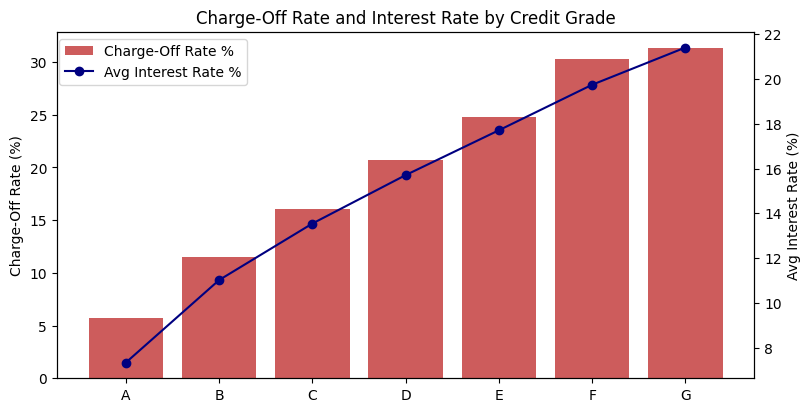

In [20]:
fig, ax1 = plt.subplots()
ax1.bar(grade_analysis['grade'], grade_analysis['Charge_Off_Rate_Pct'], color='indianred', label='Charge-Off Rate %')
ax1.set_ylabel('Charge-Off Rate (%)')
ax2 = ax1.twinx()
ax2.plot(grade_analysis['grade'], grade_analysis['Avg_Interest_Rate'], color='navy', marker='o', label='Avg Interest Rate %')
ax2.set_ylabel('Avg Interest Rate (%)')
fig.legend(loc='upper left', bbox_to_anchor=(0.12,0.88))
plt.title('Charge-Off Rate and Interest Rate by Credit Grade')
plt.show()


**Insight:** Charge-off rate rises monotonically from Grade A through Grade G, and interest rate rises in lockstep — the bank's existing grade system is well-calibrated to actual default outcomes, so grade should be a first-class input alongside DTI and rate in any tightened underwriting rule.

## 12. Answer Key — SQL Section

| # | Business Question | SQL Answer |
|---|---|---|
| 1 | How big is the loan book and how healthy is it overall? | 38,576 applications; \$435.8M funded vs \$473.1M received; 12.05% avg. rate; 13.33% avg. DTI |
| 2 | What share of the book is performing vs. defaulted? | 86.2% Good Loan (\$370.2M funded) vs 13.8% Bad Loan (\$65.5M funded, only \$37.3M recovered) |
| 3 | Is the portfolio growing over time? | Yes — funded amount rose from \$25.0M (Jan) to \$54.0M (Dec), a ~2.2x increase, with no monthly declines |
| 4 | Which states matter most? | CA, NY, TX, FL are the top 4 by funded amount, ~41% of total funding combined |
| 5 | Which loan terms and purposes dominate, and which are riskiest? | 36-month loans are ~73% of volume; Debt Consolidation is the top purpose by funding; Small Business shows a disproportionately high charge-off rate for its size |
| 6 | Which borrower segments repay most reliably? | 10+ year employment tenure and Mortgage holders show the strongest funded-to-received performance |
| 7 | Does the bank's own credit grade actually predict risk? | Yes — charge-off rate and interest rate both rise monotonically from Grade A to G, validating the grading system |

This closes out the SQL layer of the project. Borrower-level risk drivers and a predictive default model are developed next, in the Python risk-analytics notebook.
